In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Set up the pseudo-random number generator with a seed for reproducibility
rng = np.random.default_rng(3141)

# Class representing an n-sided dice
# with equal weight for each side
class Dice:
    def __init__(self, nSides = 6):
        self.n = nSides

    # Roll the dice.
    def roll(self):
        R = rng.random()
        print("R = ", R)
        p = 1./self.n # all sides have equal probability (1/6 for six-sided die)
        psum = 0 # keep running tabs on the sum
        for i in range(1,self.n+1):
            psum += p
            print(f"psum[{i}] = ", psum)
            if R < psum: # Return the first value whose comulative prob exceeds the random number
                return i

p 0.16666666666666666
psum[1] =  0.16666666666666666
p 0.16666666666666666
psum[1] =  0.16666666666666666
psum[2] =  0.3333333333333333
psum[3] =  0.5
psum[4] =  0.6666666666666666
psum[5] =  0.8333333333333333
psum[6] =  0.9999999999999999
p 0.16666666666666666
psum[1] =  0.16666666666666666
psum[2] =  0.3333333333333333
p 0.16666666666666666
psum[1] =  0.16666666666666666
psum[2] =  0.3333333333333333
psum[3] =  0.5
psum[4] =  0.6666666666666666
psum[5] =  0.8333333333333333
p 0.16666666666666666
psum[1] =  0.16666666666666666
p 0.16666666666666666
psum[1] =  0.16666666666666666
psum[2] =  0.3333333333333333
psum[3] =  0.5
psum[4] =  0.6666666666666666
psum[5] =  0.8333333333333333
psum[6] =  0.9999999999999999
p 0.16666666666666666
psum[1] =  0.16666666666666666
psum[2] =  0.3333333333333333
psum[3] =  0.5
p 0.16666666666666666
psum[1] =  0.16666666666666666
p 0.16666666666666666
psum[1] =  0.16666666666666666
p 0.16666666666666666
psum[1] =  0.16666666666666666
psum[2] =  0.3333333

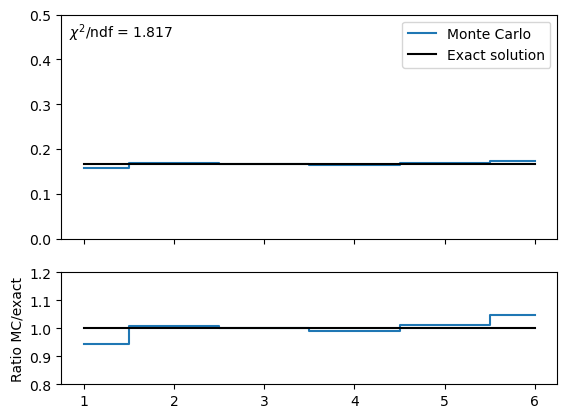

In [12]:
# Let us start by checking that our dice is fair. This means
# that all rolls should come out equally often. We roll a large
# number of dice, histogram the results, and do a ratio plot and
# a chi^2 test with the theoretical baseline
mcSamples = []
n = 6 # 6 sided dice
d = Dice(n)
mcSamples = [d.roll() for _ in range(10_000)]

# Allowed values gives our bins
dx = 1
vals = [i * dx for i in range(1,n+1)]

# Put the bin edges half-way between x-values
edges = [v - dx/2 for v in vals]
edges.append(vals[-1] + dx/2)

# Make a histogram of the result
counts, _ = np.histogram(mcSamples, bins = edges)

# Normalize the histogram
Pmc = counts / counts.sum()

# The theory baseline is 1/n for each value
yTh = [1./n for v in vals]

# Make the ratio mc/th for plotting
ratio = [mc / th for mc, th in zip(Pmc,yTh)]

# Make a chi2 test
chi2 = 0
ndf = 0
for mc, th in zip(counts,yTh):
    pth = len(mcSamples) * th # calculate chi2 on counts. rescale th value
    if pth > 5: # guard against (almost) empty bins
        chi2 += (mc - pth)**2 / pth
        ndf += 1
ndf -= 1 # here you would subtract 1 per parameter, one for the normalization

# Do the plotting
fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1])
# Make the top plot
axs[0].step(vals, Pmc, where='mid',label='Monte Carlo')
axs[0].plot(vals, yTh, color='black', label='Exact solution')
axs[0].set_ylim(0,0.5)
# Make the ratio plot
axs[1].step(vals, ratio, where='mid')
axs[1].plot(vals, [1 for _ in vals], color='black')
axs[1].set_ylim(0.8, 1.2)
# Put the chi2 on the plot
s = f"{chi2/ndf:.3f}"
axs[0].text(0.12,0.92, r"$\chi^2/$ndf = "+s, horizontalalignment='center',
            verticalalignment='center', transform=axs[0].transAxes)

axs[1].set_ylabel(r"Ratio MC/exact")
axs[0].legend()

plt.show()

In [4]:
# The theoretical distribution for sum of eyes for 10 dice
def theory(n, N):
    # PMF of one fair die
    p1 = np.ones(n) / n  # p_i = w_i / sum_i w_i

    # Convolve N dice
    p = p1
    for _ in range(N - 1):
        p = np.convolve(p, p1)
    # return the y-values, indexed by the sum-of-eyes values
    return p

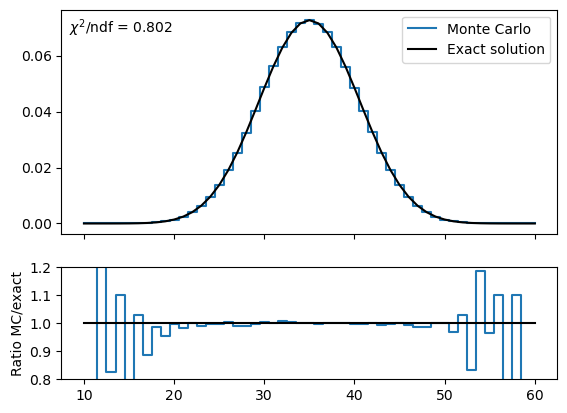

In [6]:
# Now roll 10 dice a large number of times and calculate the sum of eyes
n = 6
N = 10
M = 1000_000
mcSamples = []
d = Dice(n)
for i in range(M):
    sumEyes = 0
    for j in range(N):
        sumEyes+=d.roll()
    mcSamples.append(sumEyes)
    
# Build the histogram
# Allowed values gives our bins
dx = 1
vals = [i * dx for i in range(N,(n*N)+1)]

# Put the bin edges half-way between x-values
edges = [v - dx/2 for v in vals]
edges.append(vals[-1] + dx/2)

# Make a histogram of the result
counts, _ = np.histogram(mcSamples, bins = edges)

# Normalize the histogram
Pmc = counts / counts.sum()

# The theory baseline is calculated above
yTh = theory(n,N)

# Make the ratio mc/th for plotting
ratio = [mc / th for mc, th in zip(Pmc,yTh)]

# Make a chi2 test
chi2 = 0
ndf = 0
for mc, th in zip(counts,yTh):
    pth = len(mcSamples) * th # calculate chi2 on counts. rescale th value
    if pth > 5: # guard against (almost) empty bins
        chi2 += (mc - pth)**2 / pth
        ndf += 1
ndf -= 1 # here you would subtract 1 per parameter, one for the normalization

# Do the plotting
fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1])
# Make the top plot
axs[0].step(vals, Pmc, where='mid',label='Monte Carlo')
axs[0].plot(vals, yTh, color='black', label='Exact solution')
# Make the ratio plot
axs[1].step(vals, ratio, where='mid')
axs[1].plot(vals, [1 for _ in vals], color='black')
axs[1].set_ylim(0.8, 1.2)
# Put the chi2 on the plot
s = f"{chi2/ndf:.3f}"
axs[0].text(0.12,0.92, r"$\chi^2/$ndf = "+s, horizontalalignment='center',
            verticalalignment='center', transform=axs[0].transAxes)

axs[1].set_ylabel(r"Ratio MC/exact")
axs[0].legend()

plt.show()

In [54]:
# Exercises for you!
# 1. Change parameters around in the two examples above, and convince yourself that you understand what is going on.
# 2. The two frames are not set up very nicely code-wise. There is a lot of repeated code for plotting and calculating chi2
#    ** Define a function which takes as input two matplotlib axes objects (to become the upper and the lower part of the plots),
#       mc samples and theory values. Produce the overlaid plots, the ratio and the chi2 printed on the plot, as displayed here.
#       and return the two ax objects. Now you have reusable histogramming code, which will also be very useful in your project.
#    ** Prototype
#    def compareTHandMC(axs, mc, th):
#      ax1 = axs[0]
#      ax2 = axs[1]
#      ...
#      return ax1, ax2
# 3. You can also think about the following:
#    * when calculating the chi2 over the full range, you suffer from lack of statistics in the tails
#     is there a way to improve? what are we already doing?
#    * every bin also has a statistical error coming from the fact that we have a finite number of 
#     in each bin. Can this be quantified? Can we plot an error bar for each bin? Can this information
#     be folded in to the chi2?